# Отчет по лабораторной работе №4
**Тема:** Алгоритмы отсечения отрезков и многоугольников

## 1. Цель работы
Закрепление теоретического материала и практическое освоение основных методов и алгоритмов отсечения отрезков и многоугольников. Создание приложения, визуализирующего работу этих алгоритмов.

**Входные данные:**
Программа должна принимать данные (например, из файла) в следующем формате:
*   $n$ — число отрезков.
*   Координаты отрезков $(X1, Y1, X2, Y2)$ для $n$ линий.
*   Координаты отсекающего прямоугольного окна $(Xmin, Ymin, Xmax, Ymax)$.

**Требования к программе:**
1.  Вывести систему координат в соответствующем масштабе.
2.  Отобразить отсекающее окно одним цветом, а исходные графические примитивы (отрезки или многоугольники) — другим.
3.  Выполнить отсечение алгоритмами, соответствующими варианту.
4.  Визуализировать видимые части отрезков или многоугольников (результат отсечения).

## 3. Теоретическая часть и описание алгоритмов

### Часть 1: Отсечение отрезков прямоугольным окном

#### Описание используемого алгоритма:

*   Сазерленд-Коэн:
    Алгоритм основан на кодировании концов отрезка четырехбитным кодом в зависимости от их положения относительно границ окна (лево, право, низ, верх). Плоскость делится на 9 областей. Если оба конца имеют код 0000, отрезок полностью видим. Если логическое И кодов концов не равно нулю, отрезок полностью невидим. В остальных случаях производится поиск пересечения с границами окна и отбрасывание внешней части.

### Часть 2: Отрезков выпуклым многоугольником

#### Описание используемого алгоритма:
*   *Сазерленда-Ходжмана*
    Алгоритм работает путем последовательного отсечения списка вершин многоугольника каждой из границ отсекающего окна (или другого выпуклого многоугольника). На каждом шаге создается новый список вершин. Анализируются ребра исходного многоугольника: если ребро пересекает границу отсечения, вычисляется точка пересечения, которая добавляется в новый список.

## 5. Результаты работы программы

In [1]:
from common import create_sample_file, read_input_file
from sutherland_cohen_algorithm import sutherland_cohen_clip
from sutherland_hodgman_algorithm import sutherland_hodgman_clip

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
def plot_results(segments, window, clipped_segments, polygon, clipped_polygon):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    xmin, ymin, xmax, ymax = window
    width = xmax - xmin
    height = ymax - ymin
    
    ax1.set_title("Алгоритм Сазерленда-Коэна (Отрезки)")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    
    rect1 = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none', label='Окно')
    ax1.add_patch(rect1)
    
    # исходные отрезки
    for p1, p2 in segments:
        ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color='gray', linestyle='--', alpha=0.5)
        
    # видимые части
    if clipped_segments:
        for i, (p1, p2) in enumerate(clipped_segments):
            label = "Видимые части" if i == 0 else ""
            ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color='blue', linewidth=2, label=label)

    ax1.legend()
    ax1.grid(True)
    ax1.axhline(0, color='black', linewidth=0.5)
    ax1.axvline(0, color='black', linewidth=0.5)
    ax1.autoscale()
    
    ax2.set_title("Алгоритм Сазерленда-Ходжмана (Многоугольник)")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    
    # окно
    rect2 = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none', label='Окно')
    ax2.add_patch(rect2)
    
    # исходный многоугольник
    if polygon:
        poly_x = [p[0] for p in polygon] + [polygon[0][0]]
        poly_y = [p[1] for p in polygon] + [polygon[0][1]]
        ax2.plot(poly_x, poly_y, color='gray', linestyle='--', label='Исходный полигон')
    
    # отсеченный многоугольник
    if clipped_polygon:
        c_poly_x = [p[0] for p in clipped_polygon] + [clipped_polygon[0][0]]
        c_poly_y = [p[1] for p in clipped_polygon] + [clipped_polygon[0][1]]
        ax2.fill(c_poly_x, c_poly_y, color='green', alpha=0.3)
        ax2.plot(c_poly_x, c_poly_y, color='green', linewidth=2, label='Видимая часть')

    ax2.legend()
    ax2.grid(True)
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.axvline(0, color='black', linewidth=0.5)
    ax2.autoscale()

    plt.tight_layout()
    plt.show()


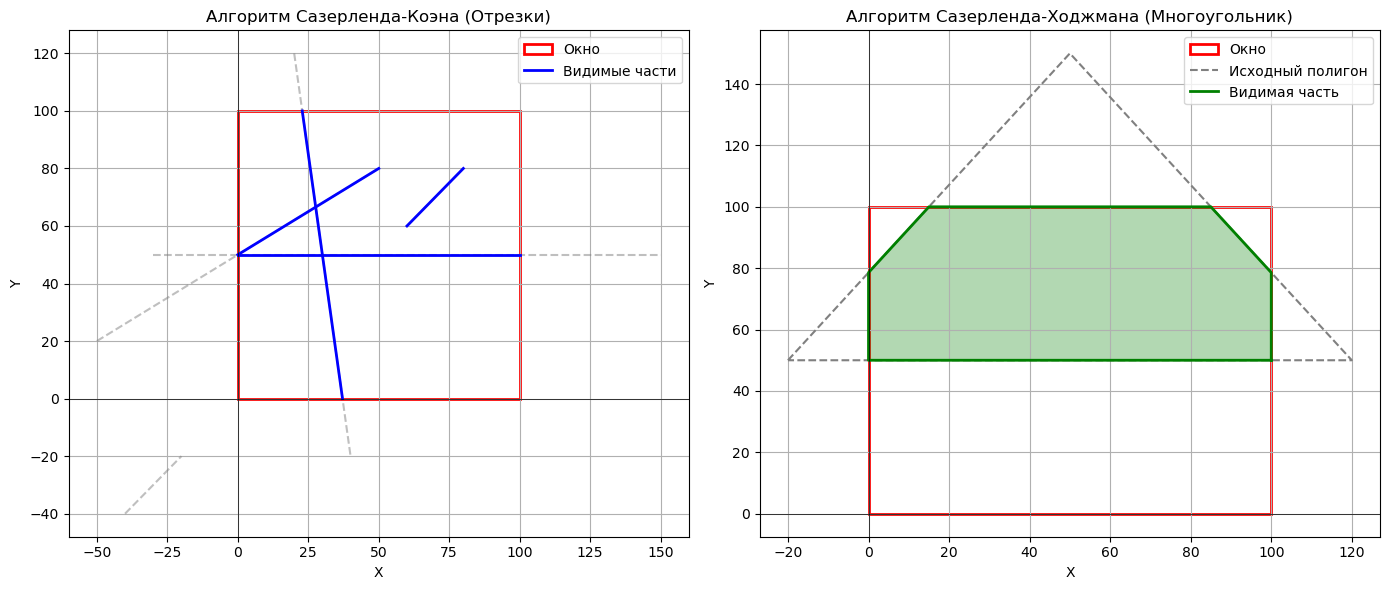

In [6]:
def main():
    create_sample_file()
    
    segments, window = read_input_file("input.txt")
    if not segments:
        return

    clipped_segments = sutherland_cohen_clip(segments, *window)
        
    polygon_example = [
        (-20, 50),
        (50, 150),
        (120, 50)
    ]
    

    clipped_polygon = sutherland_hodgman_clip(polygon_example, *window)
    plot_results(segments, window, clipped_segments, polygon_example, clipped_polygon)

if __name__ == "__main__":
    main()


## 6. Вывод
В ходе выполнения лабораторной работы были изучены и реализованы алгоритмы отсечения.
1.  Для отсечения отрезков прямоугольным окном был применен алгоритм *Сазерленд-Коэн*.
2.  Для работы с выпуклыми многоугольниками был использован метод *Сазерленда-Ходжмана*.

Работа алгоритмов проверена на различных входных данных, включая пограничные случаи. Реализованная визуализация наглядно демонстрирует процесс определения видимой части геометрических примитивов. Цель работы достигнута.